# F3NinaK — PCA por período: La Niña

**Projeto:** NINO-BRASIL — Oceanografia Física — UFPE  
**Código canônico:** `F3NinaK`  
**Objeto de estudo:** ciclo de vida da La Niña no Pacífico tropical  
**Família de hipótese:** `HIP0`

## 1. Contexto e delimitação científica

Este notebook investiga a covariação entre as 31 variáveis sem contar variáveis colineares como evidências independentes. A PCA é aplicada às médias evento-fase e descreve modos conjuntos específicos de cada período do La Niña.

## 2. Pergunta científica

Quais modos conjuntos dominam cada período do evento?

## 3. Hipótese específica

Gênese, crescimento, pico e decaimento de La Niña são dominados por combinações distintas de recarga oceânica, estado térmico e acoplamento atmosférico, expressas por cargas diferentes nos componentes principais.

A hipótese poderá ser sustentada, parcialmente sustentada ou rejeitada; a execução do notebook não antecipa o resultado.

## 4. Motivação para o teste e unidade de análise

As variáveis são padronizadas com parâmetros do conjunto analisado e a unidade é o evento-fase. A PCA é descritiva, não EOF espacial nem teste de hipótese; variância explicada e loadings devem ser lidos junto com o pequeno número de eventos.

## 5. Metodologia

PCA descritiva sobre médias evento-fase padronizadas; evento, não semana, é a unidade.

## 6. Resultados esperados e contrato de saída

Resultados esperados significam produtos necessários para responder à pergunta, não valores ou significâncias presumidos:

- variância explicada e critério de retenção por fase.
- loadings das 31 variáveis em cada componente e fase.
- interpretação física dos modos com ressalva explícita de incerteza amostral.

- figuras públicas iniciadas por `FigF3NinaK`;
- tabelas públicas iniciadas por `TabF3NinaK`;
- primeiro par reservado: `FigF3NinaK1` ↔ `TabF3NinaK1`;
- toda interpretação deve apontar para tabela, run_id, unidade, amostra e limitações.

## 7. Fundamentação científica mínima

1. Jolliffe, I. T.; Cadima, J. (2016). Principal component analysis: a review and recent developments. Philosophical Transactions A, 374, 20150202.
2. Bretherton, C. S. et al. (1999). The Effective Number of Spatial Degrees of Freedom. Journal of Climate, 12, 1990–2009.

## Premissas de validade e limites de interpretação

- Toda conclusão deve nascer de uma tabela `Tab...` persistida antes da figura correspondente.
- A execução é determinística e usa somente entradas declaradas no inventário mostrado abaixo.
- Notebook executado não implica hipótese confirmada; gates científicos são exibidos como resultados.
- El Niño e La Niña são analisados isoladamente; nenhum composto mistura os dois sinais.
- Evento é a unidade independente; semanas descrevem a trajetória interna do evento.

In [1]:
from pathlib import Path
import os
import sys
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
NOTEBOOK_CODE = 'F3NinaK'
MODE = os.environ.get('NINO26_NOTEBOOK_MODE', 'official')
RUN_PIPELINE = os.environ.get('NINO26_RUN_PIPELINE', '0') == '1'
if RUN_PIPELINE:
    raise RuntimeError('O núcleo numérico deve ser executado pelo runner da fase, antes do notebook.')
from nino_brasil.notebook_workflows import NotebookWorkflow
workflow = NotebookWorkflow(ROOT, NOTEBOOK_CODE, mode=MODE)
workflow.describe()

{
  "notebook_code": "F3NinaK",
  "phase": 3,
  "enso_type": "la_nina",
  "mode": "official",
  "execution_policy": "numeric-core-first-viewer-publisher"
}


{'notebook_code': 'F3NinaK',
 'phase': 3,
 'enso_type': 'la_nina',
 'mode': 'official',
 'execution_policy': 'numeric-core-first-viewer-publisher'}

## Dados

In [2]:
input_inventory = workflow.input_inventory()
display(input_inventory)
workflow.require_inputs()

,role,path,required,exists,bytes
0,variância PCA,data\processed\parquet\statistics\F3Nina\TabF3...,True,True,1574


## Resultados

,notebook_code,ordinal,namespace,figure_code,table_code,figure_path,table_path,manifest_path,figure_sha256,table_sha256,run_id
0,F3NinaK,1,fase3_nina,FigF3NinaK1,TabF3NinaK1,C:\DEV\NINO26\data\processed\figures\fase3_nin...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,655d42f10a0f2c86a3ccd8e9747599e44615144b6599dc...,3cc9018330fe755232e90cc62e31a32a50707b31e7326e...,20260714T202702Z_5538a635


,tipo,fase,componente,var_explicada,var_acumulada,n_eventos_independentes,n_variaveis,evaluation_mode,rotulo
0,la_nina,crescimento,PC1,0.399100,0.399100,11,31,pca_descritiva_evento_fase,crescimento | PC1
1,la_nina,crescimento,PC2,0.261264,0.660364,11,31,pca_descritiva_evento_fase,crescimento | PC2
2,la_nina,crescimento,PC3,0.094431,0.754794,11,31,pca_descritiva_evento_fase,crescimento | PC3
3,la_nina,crescimento,PC4,0.080743,0.835537,11,31,pca_descritiva_evento_fase,crescimento | PC4
4,la_nina,decaimento,PC1,0.474443,0.474443,11,31,pca_descritiva_evento_fase,decaimento | PC1
5,la_nina,decaimento,PC2,0.249968,0.724411,11,31,pca_descritiva_evento_fase,decaimento | PC2
6,la_nina,decaimento,PC3,0.096201,0.820612,11,31,pca_descritiva_evento_fase,decaimento | PC3
7,la_nina,decaimento,PC4,0.056766,0.877378,11,31,pca_descritiva_evento_fase,decaimento | PC4
8,la_nina,genese,PC1,0.535251,0.535251,11,31,pca_descritiva_evento_fase,genese | PC1
9,la_nina,genese,PC2,0.246484,0.781735,11,31,pca_descritiva_evento_fase,genese | PC2


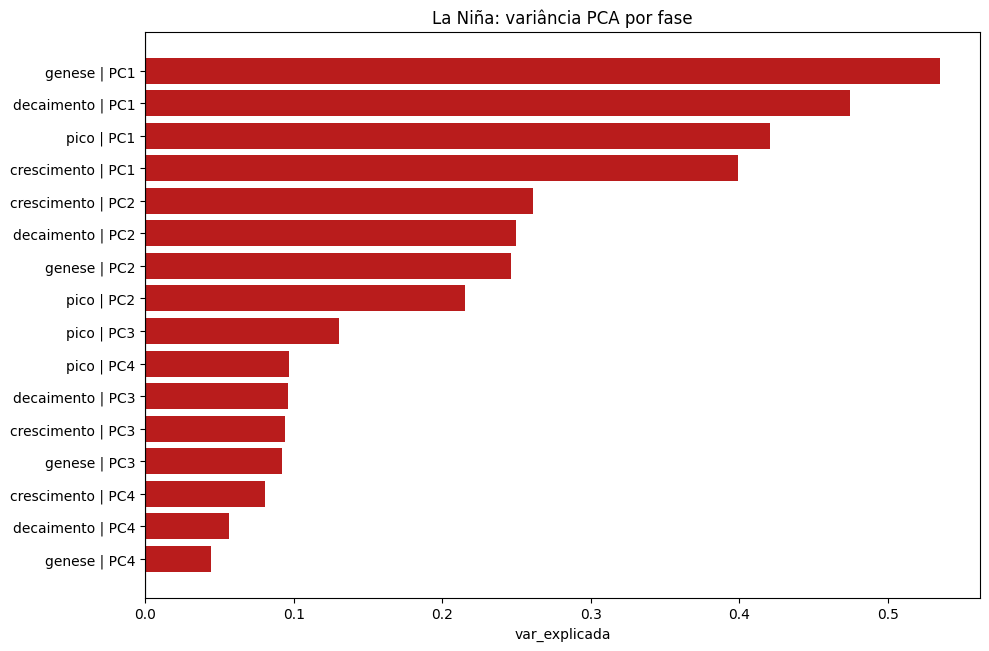

In [3]:
result = workflow.run()
display(result.artifacts)
display(result.summary)

## Figuras para verificação rápida

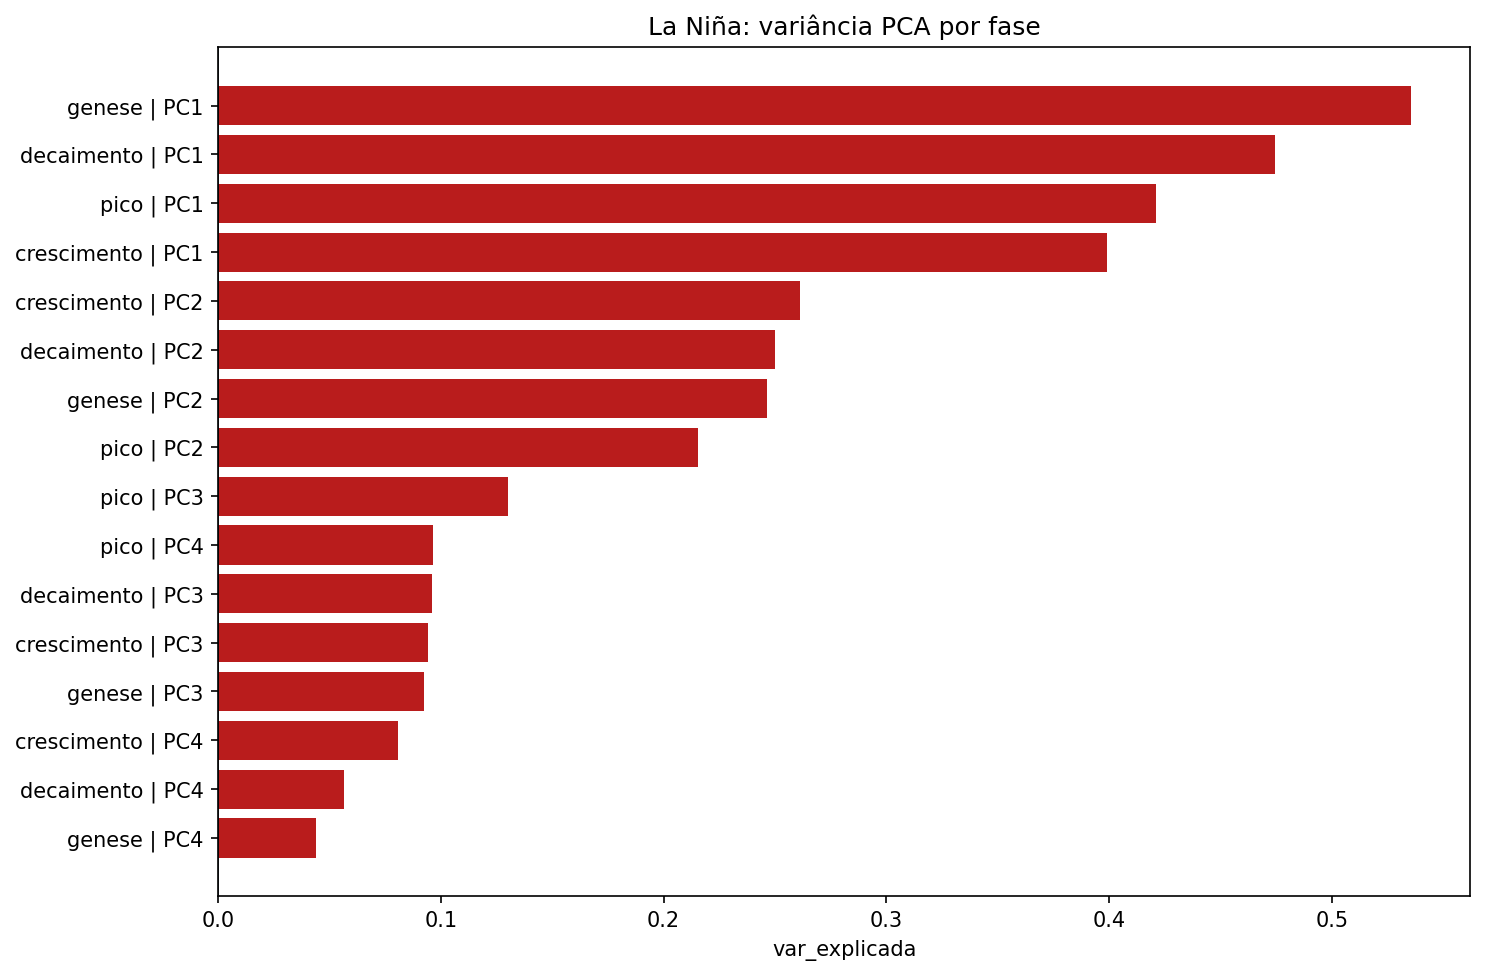

In [4]:
from IPython.display import Image, display

for artifact in result.artifacts.itertuples(index=False):
    display(Image(filename=str(artifact.figure_path)))

## Conclusões

In [5]:
for item in result.takeaways:
    print(f'- {item}')
print('\nLimitações:')
for item in result.limitations:
    print(f'- {item}')

- A tabela auditada contém 16 linhas para La Niña.
- A leitura mantém eventos independentes separados e não soma semanas como novas réplicas.

Limitações:
- A figura resume a tabela publicada; consulte a tabela completa e seu manifesto antes de interpretar valores individuais.
- Resultados negativos ou tabelas vazias são preservados e não são convertidos em falha técnica.
